In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import pytz
import matplotlib.pyplot as plt
import scipy
from arch import arch_model
from arch.univariate import GARCH
import math

In [2]:
import my_funcs

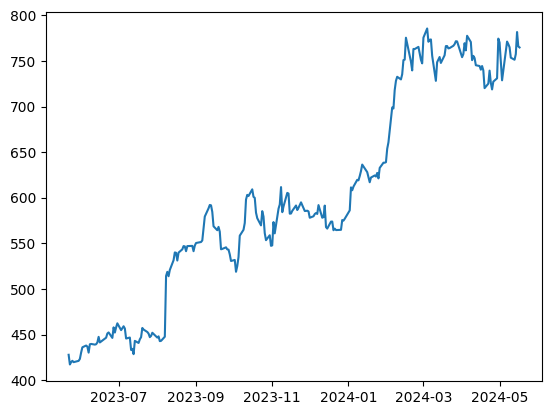

12853   -0.019148
12854   -0.025153
12855    0.006031
12856    0.003610
12857   -0.003563
           ...   
13098   -0.003031
13099    0.008254
13100    0.031415
13101   -0.020410
13102   -0.001453
Name: log_ret, Length: 250, dtype: float64

In [3]:
symbol='LLY'
start_date = datetime.datetime(2023,5,20, 0,0,0)
end_date = datetime.datetime(2024,5,20, 0,0,0)
my_funcs.get_daily_log_returns(symbol, start_date, end_date)

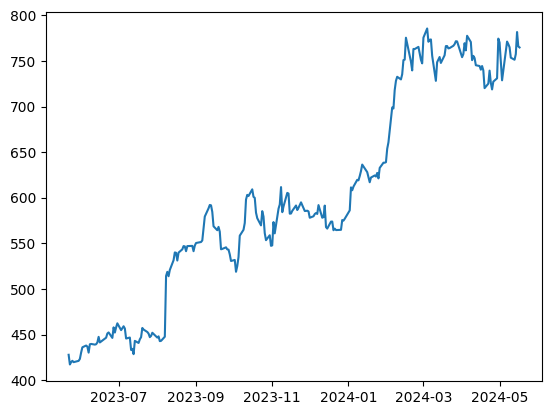

Iteration:      1,   Func. Count:      6,   Neg. LLF: 906.9952677321054
Iteration:      2,   Func. Count:     13,   Neg. LLF: 515.8221947164303
Iteration:      3,   Func. Count:     20,   Neg. LLF: 509.82062604949124
Iteration:      4,   Func. Count:     25,   Neg. LLF: 509.8189151538341
Iteration:      5,   Func. Count:     30,   Neg. LLF: 509.81065952009175
Iteration:      6,   Func. Count:     35,   Neg. LLF: 509.8001645951047
Iteration:      7,   Func. Count:     40,   Neg. LLF: 509.79026511160896
Iteration:      8,   Func. Count:     45,   Neg. LLF: 509.76174716139064
Iteration:      9,   Func. Count:     50,   Neg. LLF: 509.75937647150107
Iteration:     10,   Func. Count:     55,   Neg. LLF: 509.7570915107941
Iteration:     11,   Func. Count:     60,   Neg. LLF: 509.7568158909747
Iteration:     12,   Func. Count:     65,   Neg. LLF: 509.7567901153952
Iteration:     13,   Func. Count:     69,   Neg. LLF: 509.7567901162787
Optimization terminated successfully    (Exit mode 0)
     

In [4]:
garch_params = my_funcs.get_garch_params(my_funcs.get_daily_log_returns(symbol, start_date, end_date))

In [5]:
garch_params

mu          2.247339e-01
omega       3.456114e+00
alpha[1]    3.488568e-09
beta[1]     0.000000e+00
Name: params, dtype: float64

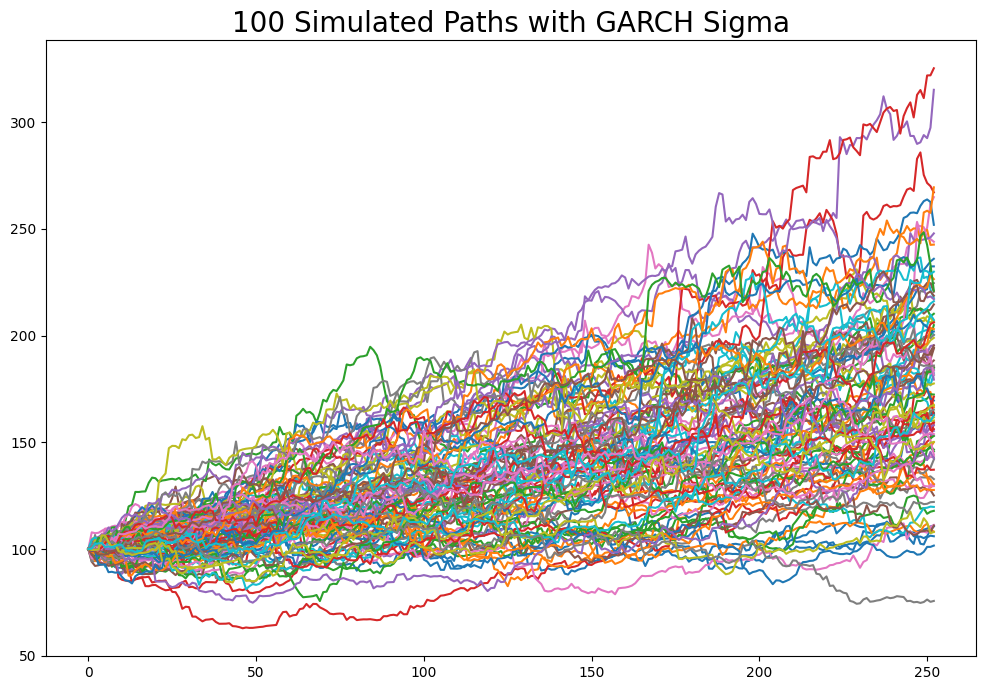

In [6]:
S0 = 100
r = 0.039
n_paths = 100
t=1

simulated_paths = my_funcs.stock_path_garch_sigma(S0, r, n_paths, t, garch_params)
simulated_paths = np.insert(simulated_paths, 0, S0, axis = 1)

plt.figure(figsize = (12,8))

for path in simulated_paths:
    plt.plot(path)
    
plt.title(f'{n_paths} Simulated Paths with GARCH Sigma', size = 20)

plt.show()

In [7]:
S0 = 100
r = 0.039
n_paths = 500
t=1
K=110

for i in range(5):
    print(my_funcs.mc_sim_call_garch(S0, K, r, n_paths, t, garch_params))

71.53345116595123
69.65583186352198
71.02519690203036
67.1230554109997
68.50962429284118


In [8]:
S0 = np.array([[100], [100]])
r = 0.039
n_paths = 100
K=110
t=1

my_funcs.mc_sim_call_garch_delta(S0, K, t, r, n_paths, garch_params)

array([0.46602143, 0.46602143])

In [9]:
S0 = 100
r = 0.039
n_paths = 5
K=120
t=1

my_funcs.mc_sim_call_garch_delta_hedge(S0, K, garch_params, r, t, n_sims = 5, n_hedges = 3, delta_sims = 500)

array([ 1.35903247, 16.82221124, 26.3706587 , 15.29908063, 10.84078596])

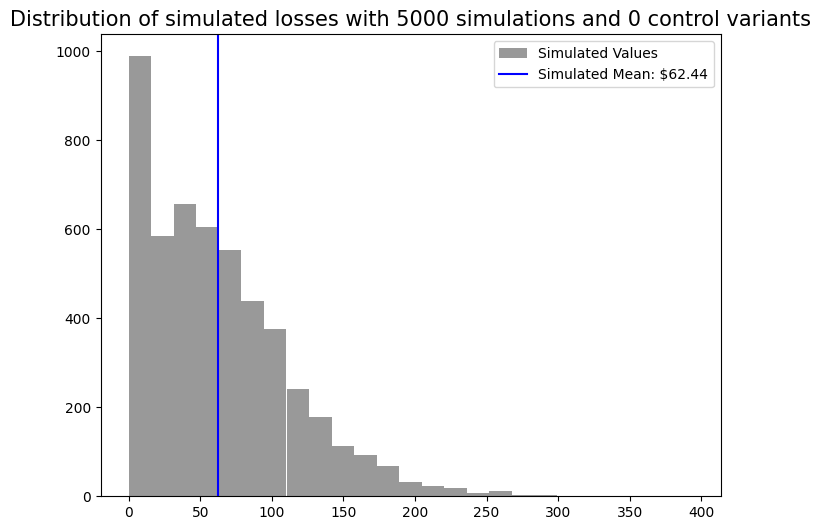

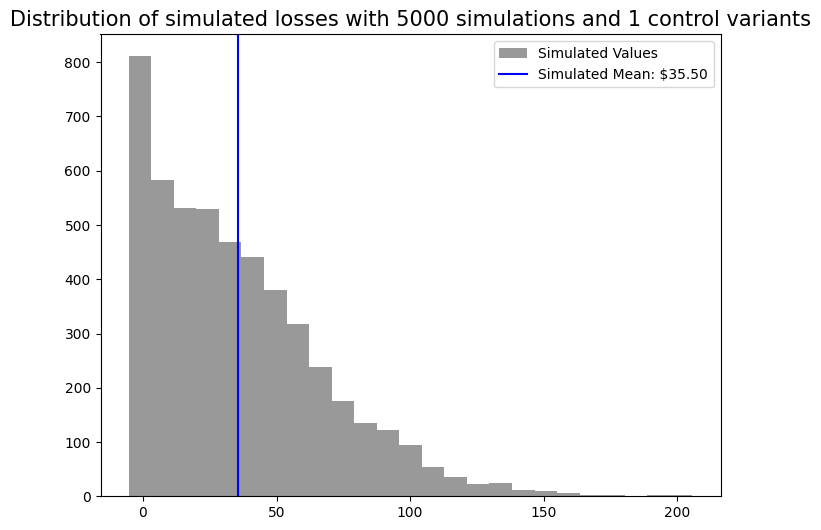

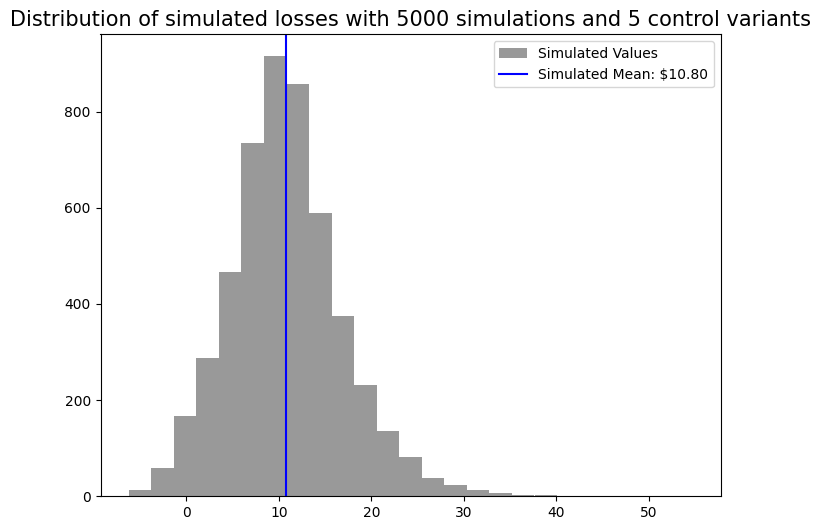

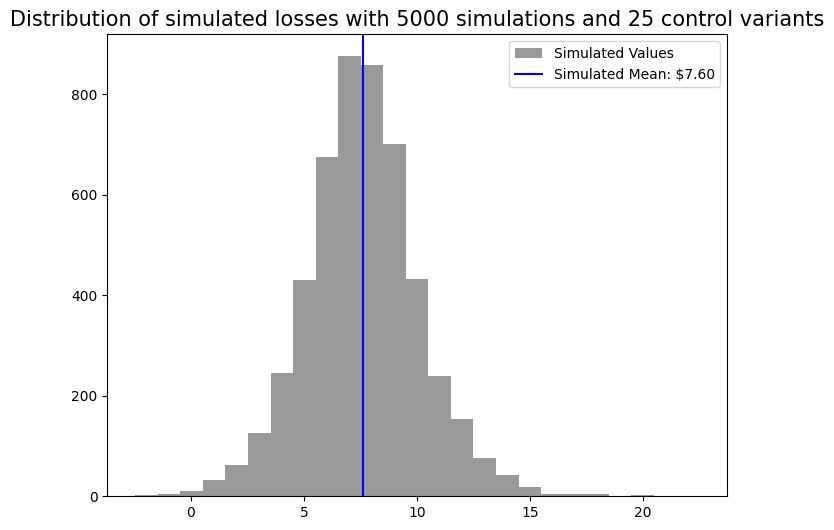

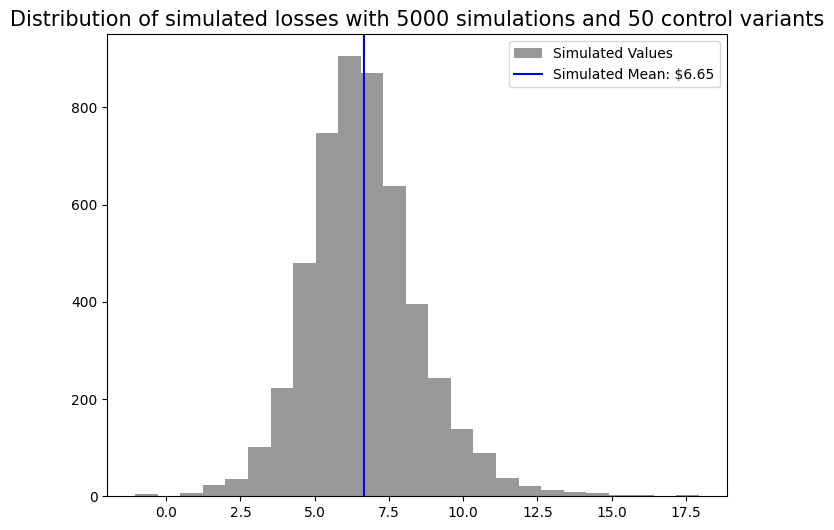

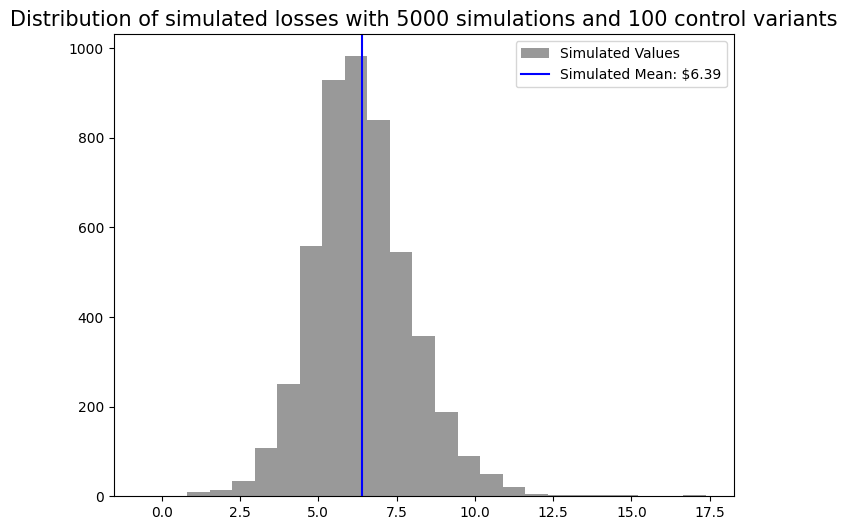

In [12]:
S0 = 100
K = 120
#sigma = .5
t = 1
r = 0.04
#mu = .35 #Drift of stock movement
delta_sims = 500

n_sims = 5000

hedging_numbers = [0, 1, 5, 25, 50, 100]

#bs_price = bs_call(S0,K,sigma,t,r)

for n_hedges in hedging_numbers:
    profits_hedged = my_funcs.mc_sim_call_garch_delta_hedge(S0, K, garch_params, r, t, n_sims , n_hedges, delta_sims)
    
    plt.figure(figsize = (8,6))
    
    plt.hist(profits_hedged, bins = 25, alpha = .4, color = 'black', label = 'Simulated Values')
        
    plt.axvline(np.mean(profits_hedged), label = f'Simulated Mean: ${np.mean(profits_hedged):.2f}', color = 'blue')
    
    plt.legend()
    
    plt.title(f'Distribution of simulated losses with {n_sims} simulations and \
{n_hedges} control variants',size = 15)
    
    plt.show()
